In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import tensorflow as tf

efficientnet_model = tf.keras.models.load_model(
    r"efficientnetb3_best.keras"
)

densenet_model = tf.keras.models.load_model(
    r"densenet121_best.keras"
)

print("EfficientNet loaded")
print("DenseNet loaded")

EfficientNet loaded
DenseNet loaded


In [3]:
efficientnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,969,350 (45.66 MB)

 Trainable params: 395,271 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

 Optimizer params: 790,544 (3.02 MB)

In [4]:
densenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,830,103 (29.87 MB)

 Trainable params: 264,199 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 528,400 (2.02 MB)

In [5]:
from tensorflow.keras import Model

efficientnet_features = Model(
    inputs=efficientnet_model.input,
    outputs=efficientnet_model.get_layer(
        "global_average_pooling2d"
    ).output
)

densenet_features = Model(
    inputs=densenet_model.input,
    outputs=densenet_model.get_layer(
        "global_average_pooling2d"
    ).output
)

efficientnet_features.trainable = False
densenet_features.trainable = False

print("EfficientNet feature extractor ready")
print("DenseNet feature extractor ready")

EfficientNet feature extractor ready
DenseNet feature extractor ready


In [6]:
print("EfficientNet feature shape:",
      efficientnet_features.output.shape)

print("DenseNet feature shape:",
      densenet_features.output.shape)

EfficientNet feature shape: (None, 1536)
DenseNet feature shape: (None, 1024)


In [7]:
from tensorflow.keras import layers, Model
import tensorflow as tf

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="hybrid_input"
)

# EfficientNetB3 branch
efficient_features = efficientnet_features(inputs)

# DenseNet121 branch
dense_features = densenet_features(inputs)

# Combine both feature vectors
combined_features = layers.Concatenate(
    name="feature_fusion"
)([
    efficient_features,
    dense_features
])

print("Combined feature shape:", combined_features.shape)

# Classification head
x = layers.Dense(
    512,
    activation="relu",
    name="fusion_dense_512"
)(combined_features)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu",
    name="fusion_dense_256"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    7,
    activation="softmax",
    name="hybrid_output"
)(x)

hybrid_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB3_DenseNet121_Hybrid"
)

hybrid_model.summary()

Combined feature shape: (None, 2560)


Model: "EfficientNetB3_DenseNet121_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hybrid_input        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 1536)      │ 10,783,535 │ hybrid_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 1024)      │  7,037,504 │ hybrid_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2560)      │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ functional_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_512    │ (None, 512)       │  1,311,232 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ fusion_dense_512… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_256    │ (None, 256)       │    131,328 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ fusion_dense_256… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_output       │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,267,446 (73.50 MB)

 Trainable params: 1,445,383 (5.51 MB)

 Non-trainable params: 17,822,063 (67.99 MB)

In [8]:
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Hybrid model compiled successfully.")

Hybrid model compiled successfully.


In [9]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "efficientnet_densenet_hybrid_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [11]:
import os
import tensorflow as tf

DATASET_PATH = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 1811 files belonging to 7 classes.
Found 362 files belonging to 7 classes.
Found 365 files belonging to 7 classes.
Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'leaf_smut', 'narrow_brown_spot']
Number of classes: 7


In [12]:
history = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3675 - loss: 2.0472
Epoch 1: val_accuracy improved from None to 0.67127, saving model to efficientnet_densenet_hybrid_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.5262 - loss: 1.4917 - val_accuracy: 0.6713 - val_loss: 1.0092 - learning_rate: 1.0000e-04
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7468 - loss: 0.7165
Epoch 2: val_accuracy improved from 0.67127 to 0.85635, saving model to efficientnet_densenet_hybrid_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.7703 - loss: 0.6665 - val_accuracy: 0.8564 - val_loss: 0.5935 - learning_rate: 1.0000e-04
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8493 - loss: 0.4755
Epoch 3: val_accuracy improved from 0.85635 to 0.90331, saving model to efficientnet_densenet_hybrid_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.8515 - loss: 0.4343 - val_accuracy: 0.9033 - val_loss: 0.3826 - learning_rat

In [13]:
test_loss, test_accuracy = hybrid_model.evaluate(test_ds, verbose=1)

print("====================================")
print("Hybrid Test Loss      :", test_loss)
print("Hybrid Test Accuracy  :", test_accuracy)
print("Hybrid Test Accuracy %:", test_accuracy * 100)
print("====================================")

12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.9616 - loss: 0.1034
Hybrid Test Loss      : 0.10340630263090134
Hybrid Test Accuracy  : 0.9616438150405884
Hybrid Test Accuracy %: 96.16438150405884


In [14]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = hybrid_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                       precision    recall  f1-score   support

bacterial_leaf_blight     0.9821    1.0000    0.9910        55
           brown_spot     0.9636    0.8983    0.9298        59
              healthy     0.9846    0.9697    0.9771        66
           leaf_blast     0.8696    0.9524    0.9091        63
           leaf_scald     1.0000    0.9630    0.9811        54
            leaf_smut     1.0000    0.8333    0.9091         6
    narrow_brown_spot     0.9841    1.0000    0.9920        62

             accuracy                         0.9616       365
            macro avg     0.9692    0.9452    0.9556       365
         weighted avg     0.9634    0.9616    0.9618       365



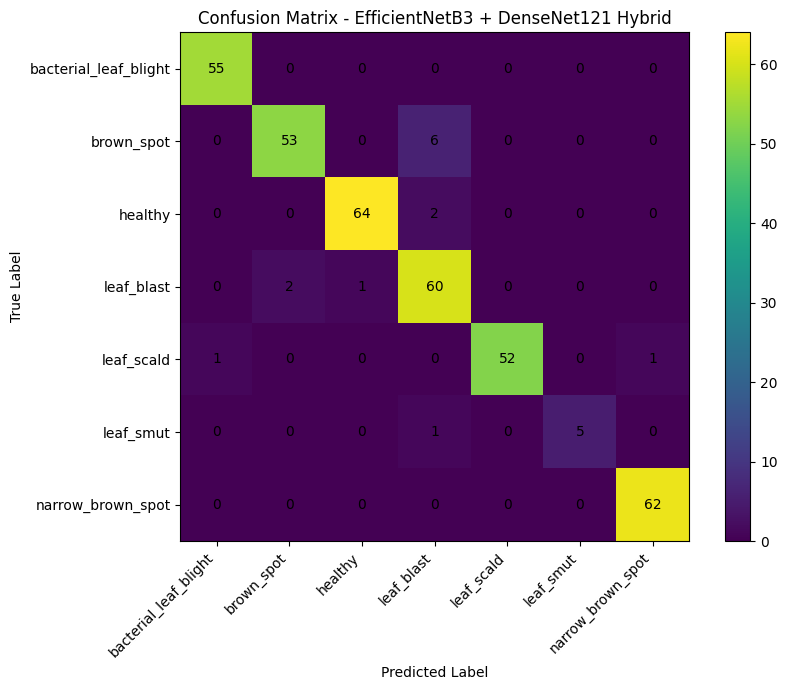

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix - EfficientNetB3 + DenseNet121 Hybrid")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [1]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

In [3]:
hybrid_model = tf.keras.models.load_model(
    r"C:\Users\sujan\Desktop\final project2\DATASET\efficientnet_densenet_hybrid_best.keras"
)

In [4]:
DATASET_PATH = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset"

TEST_DIR = os.path.join(DATASET_PATH, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = test_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.prefetch(AUTOTUNE)

Found 365 files belonging to 7 classes.


In [5]:
test_loss, test_accuracy = hybrid_model.evaluate(test_ds)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)
print("Test Accuracy % :", test_accuracy * 100)

12/12 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9726 - loss: 0.0933
Test Loss : 0.09329980611801147
Test Accuracy : 0.9726027250289917
Test Accuracy % : 97.26027250289917


In [6]:
print(hybrid_model.name)
print(hybrid_model.summary())

EfficientNetB3_DenseNet121_Hybrid


Model: "EfficientNetB3_DenseNet121_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hybrid_input        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 1536)      │ 10,783,535 │ hybrid_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 1024)      │  7,037,504 │ hybrid_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2560)      │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ functional_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_512    │ (None, 512)       │  1,311,232 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ fusion_dense_512… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_256    │ (None, 256)       │    131,328 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ fusion_dense_256… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_output       │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,158,214 (84.53 MB)

 Trainable params: 1,445,383 (5.51 MB)

 Non-trainable params: 17,822,063 (67.99 MB)

 Optimizer params: 2,890,768 (11.03 MB)

None


In [8]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = hybrid_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                       precision    recall  f1-score   support

bacterial_leaf_blight     1.0000    1.0000    1.0000        55
           brown_spot     0.9636    0.8983    0.9298        59
              healthy     0.9706    1.0000    0.9851        66
           leaf_blast     0.9091    0.9524    0.9302        63
           leaf_scald     1.0000    1.0000    1.0000        54
            leaf_smut     1.0000    0.8333    0.9091         6
    narrow_brown_spot     1.0000    1.0000    1.0000        62

             accuracy                         0.9726       365
            macro avg     0.9776    0.9549    0.9649       365
         weighted avg     0.9731    0.9726    0.9724       365



In [9]:
hybrid_model = tf.keras.models.load_model("efficientnet_densenet_hybrid_best.keras")
test_loss, test_accuracy = hybrid_model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9726 - loss: 0.0933


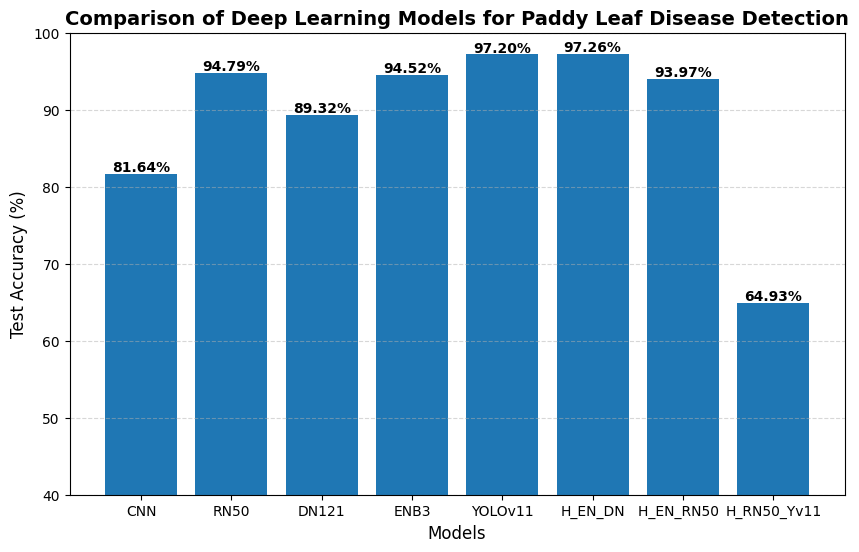

✅ Bar graph saved as 'Model_Comparison_Bar_Graph.png'


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Model Results
results = pd.DataFrame({
    "Model": [
        "CNN",
        "RN50",
        "DN121",
        "ENB3",
        "YOLOv11",
        "H_EN_DN",
        "H_EN_RN50  ",
        "H_RN50_Yv11"
    ],
    
    "Accuracy": [
        81.64,
        94.79,
        89.32,
        94.52,
        97.20,
        97.26,
        93.97,
        64.93
    ]
})

# Create Bar Graph
plt.figure(figsize=(10, 6))

bars = plt.bar(results["Model"], results["Accuracy"])

plt.title("Comparison of Deep Learning Models for Paddy Leaf Disease Detection",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)

plt.ylim(40, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display accuracy values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.3,
             f"{height:.2f}%",
             ha='center',
             fontsize=10,
             fontweight='bold')

# Save graph
plt.savefig("Model_Comparison_Bar_Graph.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ Bar graph saved as 'Model_Comparison_Bar_Graph.png'")

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report

# ============================================================
# 1. Paths
# ============================================================

model_path = r"C:\Users\sujan\Desktop\final project2\DATASET\cnn_densenet121_best.keras"

test_path = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\test"

# ============================================================
# 2. Load model
# ============================================================

model = load_model(model_path)

print("Model loaded successfully!")

# ============================================================
# 3. Load test dataset
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = test_ds.class_names

print("\nClasses:")
print(class_names)

# ============================================================
# 4. Get predictions
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:
    
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ============================================================
# 5. Accuracy
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

print("\n" + "=" * 65)
print("CNN + DenseNet121 HYBRID RESULTS")
print("=" * 65)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

# ============================================================
# 6. Classification Report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Model loaded successfully!
Found 365 files belonging to 7 classes.

Classes:
['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'leaf_smut', 'narrow_brown_spot']

CNN + DenseNet121 HYBRID RESULTS
Accuracy: 0.8932
Accuracy: 89.32%

Classification Report:

                       precision    recall  f1-score   support

bacterial_leaf_blight     0.9818    0.9818    0.9818        55
           brown_spot     0.8400    0.7119    0.7706        59
              healthy     0.9014    0.9697    0.9343        66
           leaf_blast     0.8214    0.7302    0.7731        63
           leaf_scald     1.0000    0.9630    0.9811        54
            leaf_smut     0.6667    1.0000    0.8000         6
    narrow_brown_spot     0.8611    1.0000    0.9254        62

             accuracy                         0.8932       365
            macro avg     0.8675    0.9081    0.8809       365
         weighted avg     0.8937    0.8932    0.8904       365

